#Análisis Pokemon (porque sí)

Un día estaba aburrida en mi casa y me encontré con un dataset de Pokémon. Pensé en hacer un análisis random de cosas que nadie me pidió y salió esto.

Usando Python, Pandas, Matplotlib y Seaborn, me puse a responder preguntas:

- Los Pokémon legendarios son realmente más fuertes?

- Qué tipo tiene más ataque o defensa?

- Quién ganaría una batalla entre Turtwig y Piplup?

- Cuál es la generación más poderosa?

Hay gráficos, tablas y hasta mini análisis de batallas.
Todo hecho con amor, muchos vasitos de agua y ganas de crear 💕

In [2]:
import pandas as pd

df = pd.read_csv('Pokemon_data.txt')

# Primeras filas
print(df.head())


  #\tName\tType 1\tType 2\tHP\tAttack\tDefense\tSp. Atk\tSp. Def\tSpeed\tGeneration\tLegendary
0  1\tBulbasaur\tGrass\tPoison\t45\t49\t49\t65\t6...                                          
1  2\tIvysaur\tGrass\tPoison\t60\t62\t63\t80\t80\...                                          
2  3\tVenusaur\tGrass\tPoison\t80\t82\t83\t100\t1...                                          
3  3\tVenusaurMega Venusaur\tGrass\tPoison\t80\t1...                                          
4  4\tCharmander\tFire\t\t39\t52\t43\t60\t50\t65\...                                          


In [8]:
print(df.dtypes)


#\tName\tType 1\tType 2\tHP\tAttack\tDefense\tSp. Atk\tSp. Def\tSpeed\tGeneration\tLegendary    object
dtype: object


# ❗Corrección

Antes de empezar, veo que el archivo no está separado por comas, sino por tabulaciones (\t), y además no se parseó correctamente, por eso vemos todas las columnas en una sola.

Lo corregimos con el siguiente código:

In [3]:
import pandas as pd

# Cargamos el archivo con tabulaciones como separador
df = pd.read_csv('Pokemon_data.txt', delimiter='\t')

# Limpiamos espacios en columnas
df.columns = df.columns.str.strip()

# Verificamos columnas
print(df.columns.tolist())
print(df.head())


['#', 'Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']
   #                   Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  \
0  1              Bulbasaur  Grass  Poison  45      49       49       65   
1  2                Ivysaur  Grass  Poison  60      62       63       80   
2  3               Venusaur  Grass  Poison  80      82       83      100   
3  3  VenusaurMega Venusaur  Grass  Poison  80     100      123      122   
4  4             Charmander   Fire     NaN  39      52       43       60   

   Sp. Def  Speed  Generation  Legendary  
0       65     45           1      False  
1       80     60           1      False  
2      100     80           1      False  
3      120     80           1      False  
4       50     65           1      False  


# 💡 Pokemon legendarios vs no legendarios

¿Tienen mejores estadísticas en promedio que los no legendarios?

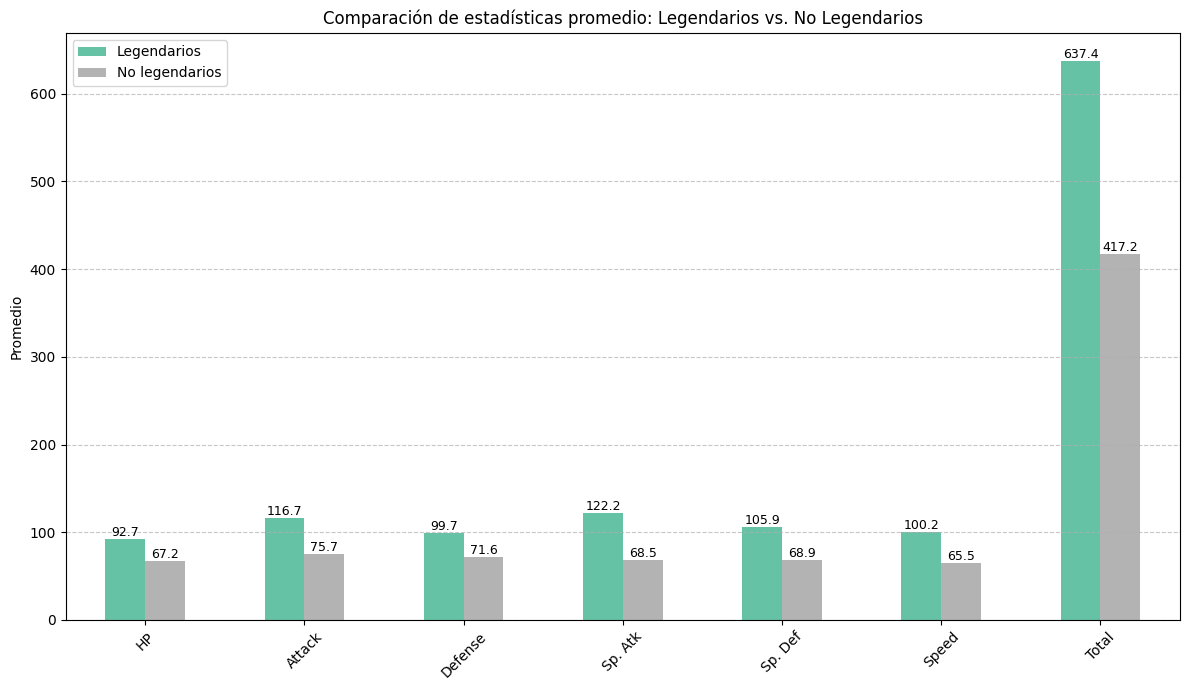

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Creamos la columna 'Total'
df["Total"] = df[["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]].sum(axis=1)

# Separamos en leg vs no leg
df_legendarios = df[df["Legendary"] == True]
df_no_legendarios = df[df["Legendary"] == False]

# Stats a comparar
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Total']

# Promedios
promedios_legendarios = df_legendarios[stats].mean()
promedios_no_legendarios = df_no_legendarios[stats].mean()

# Creamos df para comparar
df_comparacion = pd.DataFrame({
    "Legendarios": promedios_legendarios,
    "No legendarios": promedios_no_legendarios
})

# Gráfico con valores
ax = df_comparacion.plot(kind="bar", figsize=(12, 7), colormap="Set2")

plt.title("Comparación de estadísticas promedio: Legendarios vs. No Legendarios")
plt.ylabel("Promedio")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Etiquetas
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}',  # texto con 1 decimal
                (p.get_x() + p.get_width() / 2, height),  # posición
                ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.tight_layout()
plt.show()

👆 Los Pokémon legendarios destacan por su superioridad en casi todas las estadísticas base, especialmente en ataque especial y velocidad, lo que los hace más poderosos y versátiles en batalla. Esta diferencia numérica explica por qué suelen ser considerados más fuertes y raros.

# 💡 Tipos más ofensivos y defensivos

¿Qué tipo de Pokémon es el más ofensivo y cuál el más defensivo?

In [36]:
# Stats ofensivas y defensivas
df['Offense'] = df['Attack'] + df['Sp. Atk']
df['Defense_total'] = df['Defense'] + df['Sp. Def']

# Agrupación por Type 1 (tipo principal)
tipo_stats = df.groupby('Type 1').agg({
    'Offense': 'mean',
    'Defense_total': 'mean'
}).sort_values(by='Offense', ascending=False)

print("Tipos con mayor ofensiva promedio:")
print(tipo_stats['Offense'].head(5))

print("\nTipos con mayor defensa promedio:")
print(tipo_stats.sort_values(by='Defense_total', ascending=False)['Defense_total'].head(5))


Tipos con mayor ofensiva promedio:
Type 1
Dragon     208.968750
Fire       173.750000
Flying     173.000000
Psychic    169.859649
Dark       163.032258
Name: Offense, dtype: float64

Tipos con mayor defensa promedio:
Type 1
Steel      207.000000
Rock       176.272727
Dragon     175.218750
Ghost      157.656250
Psychic    153.964912
Name: Defense_total, dtype: float64


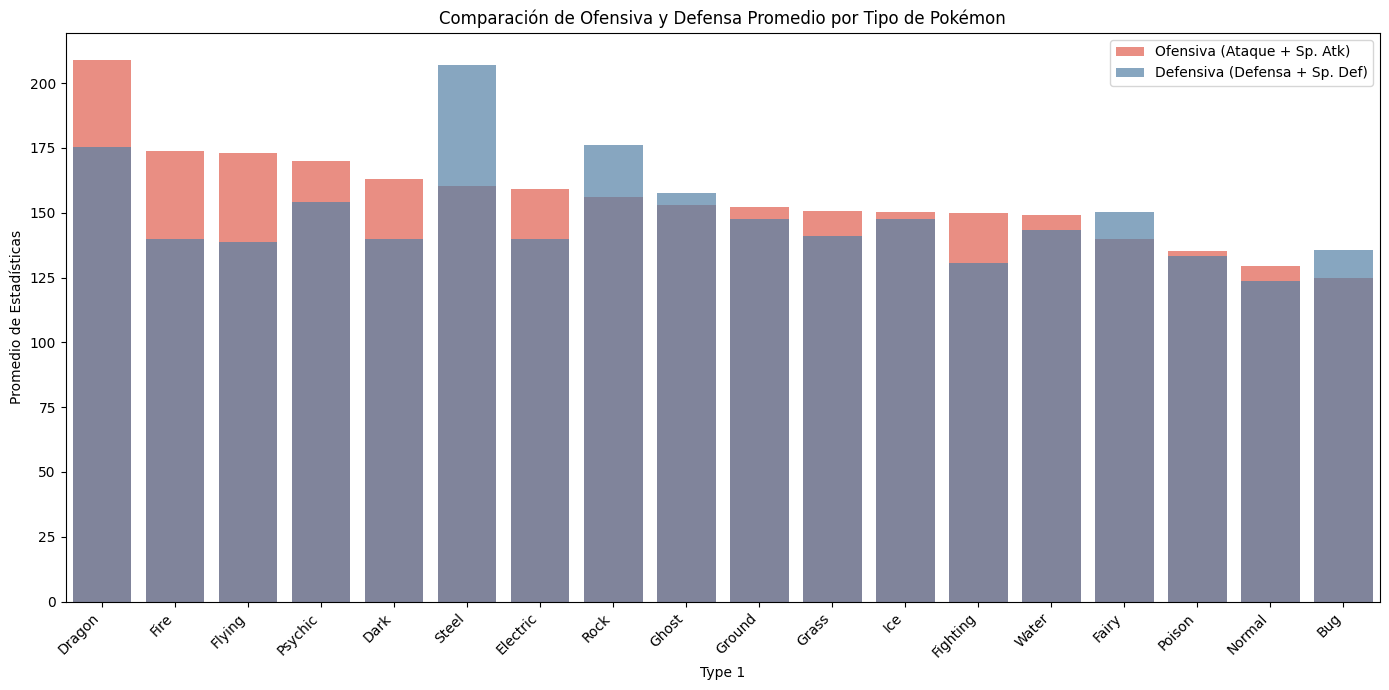

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# df tipo_stats que ya tiene Offense y Defense_total promedio por tipo
tipo_stats_sorted = tipo_stats.sort_values(by='Offense', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(x=tipo_stats_sorted.index, y=tipo_stats_sorted['Offense'], color='salmon', label='Ofensiva (Ataque + Sp. Atk)')
sns.barplot(x=tipo_stats_sorted.index, y=tipo_stats_sorted['Defense_total'], color='steelblue', alpha=0.7, label='Defensiva (Defensa + Sp. Def)')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Promedio de Estadísticas')
plt.title('Comparación de Ofensiva y Defensa Promedio por Tipo de Pokémon')
plt.legend()
plt.tight_layout()
plt.show()

# ⚔ Tipo más ofensivo
Los Pokémon de tipo Dragón 🐉 son los más ofensivos en promedio, con una suma de ataque físico y especial cercana a 209 puntos, superando por bastante a otros tipos. Es especial, ya que aparece tanto entre los más ofensivos como entre los más defensivos, mostrando una combinación muy equilibrada y poderosa.

# 🛡 Tipo más defensivo
Los Pokémon de tipo Acero 🪨 destacan por tener la mayor defensa promedio (207 puntos combinados entre defensa física y especial), seguidos por los tipos Roca, Dragón, Fantasma y Psíquico. Tipos como Fuego y Volador están más enfocados en la ofensiva.

# 💡¿Quién ganaría en una batalla Turtwig vs Piplup?
Usamos sus estadísticas base y consideramos la ventaja de tipo para estimar quién tiene más probabilidades de ganar una batalla.

In [40]:
# Filtro datos de ambos
turtwig = df[df['Name'] == 'Turtwig'].iloc[0]
piplup = df[df['Name'] == 'Piplup'].iloc[0]

print("Turtwig stats:")
print(turtwig[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']])

print("\nPiplup stats:")
print(piplup[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']])

Turtwig stats:
HP         55
Attack     68
Defense    64
Sp. Atk    45
Sp. Def    55
Speed      31
Name: 432, dtype: object

Piplup stats:
HP         53
Attack     51
Defense    53
Sp. Atk    61
Sp. Def    56
Speed      40
Name: 438, dtype: object


# ⚡ Análisis rápido
🦾 Ventaja de tipo: Piplup (Agua) tiene ventaja sobre Turtwig (Planta), lo que hace que sus ataques de tipo Agua inflijan más daño.

⚔ Ofensiva: Turtwig destaca en ataque físico, pero Piplup gana en ataque especial y velocidad.

🛡 Defensa: Turtwig tiene mejor defensa física, pero Piplup es más rápido para atacar primero.

# Estimación de daño ajustado por tipo
Para entender mejor quién tiene ventaja ofensiva, calculamos un daño estimado considerando el tipo de ataque más probable y el modificador de tipo:

In [41]:
# Stats ofensivos
turtwig_attack = 68     # Ataque físico
turtwig_sp_atk = 45     # Ataque especial

piplup_attack = 51
piplup_sp_atk = 61

# Multiplicadores de tipo (ataques físicos/planta y especiales/agua)
mod_turtwig = 0.5  # Planta vs Agua, poco efectivo
mod_piplup = 1.5   # Agua vs Planta, super efectivo

# Estimación de daño (ataque más alto x mod)
# Supongamos que Turtwig ataca físicamente, Piplup ataca especial (lo más común)

damage_turtwig = turtwig_attack * mod_turtwig
damage_piplup = piplup_sp_atk * mod_piplup

print(f"Daño estimado de Turtwig (ataque físico, planta): {damage_turtwig:.2f}")
print(f"Daño estimado de Piplup (ataque especial, agua): {damage_piplup:.2f}")


Daño estimado de Turtwig (ataque físico, planta): 34.00
Daño estimado de Piplup (ataque especial, agua): 91.50


# 🐧 ¿Quién gana? 🐢

Piplup tiene una clara ventaja ofensiva debido a su tipo Agua y su alto ataque especial, combinados con un multiplicador de daño favorable. Además, su mayor velocidad le permite atacar primero, lo cual es crucial en combate.

Aunque Turtwig tiene mejor defensa y ataque físico, su daño se ve reducido por la desventaja de tipo y su menor ataque especial.

Entonces, Piplup ganaría la batalla! 🐧🥇

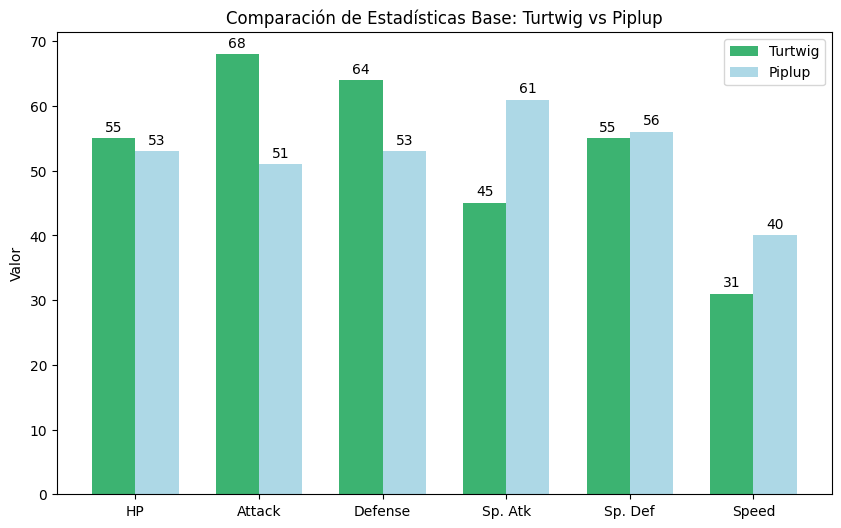

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Stats
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
turtwig_stats = [55, 68, 64, 45, 55, 31]
piplup_stats = [53, 51, 53, 61, 56, 40]

x = np.arange(len(stats))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, turtwig_stats, width, label='Turtwig', color='mediumseagreen')
bars2 = ax.bar(x + width/2, piplup_stats, width, label='Piplup', color='lightblue')

ax.set_ylabel('Valor')
ax.set_title('Comparación de Estadísticas Base: Turtwig vs Piplup')
ax.set_xticks(x)
ax.set_xticklabels(stats)
ax.legend()

def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),  # el desplazamiento vertical
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bars1)
autolabel(bars2)

plt.show()

# 🧬 ¿Qué generación tiene los Pokémon más poderosos?

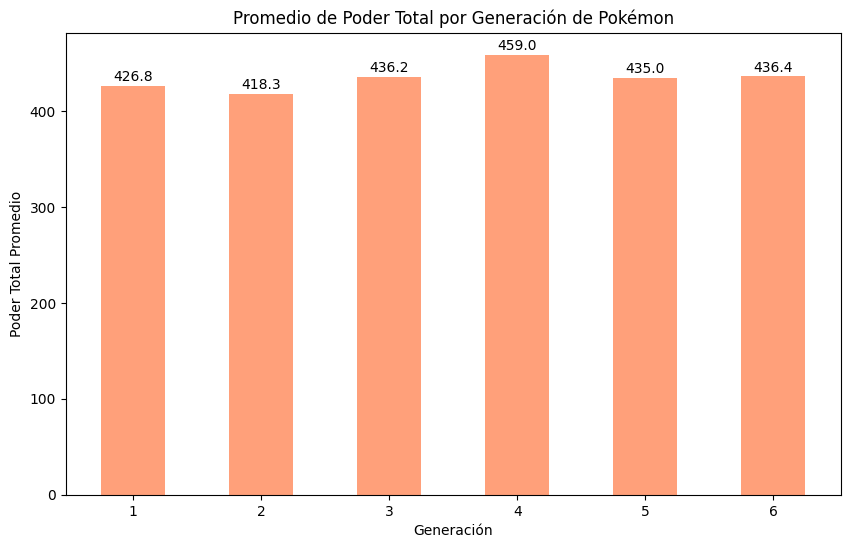

In [10]:
import matplotlib.pyplot as plt

df['Total'] = pd.to_numeric(df['Total'], errors='coerce')

# Agrupo por generación y calcular el promedio de Total
promedio_por_generacion = df.groupby('Generation')['Total'].mean()

# Gráfico
plt.figure(figsize=(10,6))
bars = plt.bar(promedio_por_generacion.index, promedio_por_generacion.values, color='#FFA07A', width=0.5)
plt.title('Promedio de Poder Total por Generación de Pokémon')
plt.xlabel('Generación')
plt.ylabel('Poder Total Promedio')
plt.xticks(rotation=0)

# Valores de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}', ha='center', va='bottom')

plt.show()

Al analizar el poder total promedio por generación, encontré que la 4ta generación destaca como la más poderosa con un promedio de 459 puntos. Esto indica que, en general, los Pokémon introducidos en la región Sinnoh tienen estadísticas base más altas en comparación con otras generaciones.

Este resultado puede deberse a la inclusión de varios Pokémon legendarios en Sinnoh. Por ejemplo, Pokémon icónicos como Garchomp y Dialga pertenecen a esta generación y contribuyen significativamente al promedio.

Igualmente, voy a detectar cuántos legendarios hay por generación y filtrarlos del análisis de la siguiente manera:

In [8]:
# Filtro solo los Pokémon legendarios y contar por generación
legendarios_por_gen = df[df['Legendary'] == True]['Generation'].value_counts().sort_index()

tabla_legendarios = legendarios_por_gen.reset_index()
tabla_legendarios.columns = ['Generación', 'Cantidad de Legendarios']
print(tabla_legendarios)

   Generación  Cantidad de Legendarios
0           1                        6
1           2                        5
2           3                       18
3           4                       13
4           5                       15
5           6                        8


# 🧬 ¿Qué generación tiene los Pokémon más poderosos?

Después de calcular el promedio total de estadísticas base de cada generación, observamos que la 4ta generación se destacaba con un promedio de 459 puntos. Esto me llevó a preguntarme si este valor tan alto se debía a la presencia de Pokémon legendarios.

Para comprobarlo, excluí a los Pokémon legendarios del análisis y recalculé los promedios. Lo hacemos de la siguiente manera:

In [9]:
df['Legendary'] = df['Legendary'].astype(bool)

# Filtro solo los Pokémon no legendarios
df_no_legendarios = df[~df['Legendary']]

# Agrupo por generación y calculo el promedio del total de estadísticas
promedio_sin_legendarios = df_no_legendarios.groupby('Generation')['Total'].mean().reset_index()

# Renombro columnas para claridad
promedio_sin_legendarios.columns = ['Generación', 'Promedio sin legendarios']

print(promedio_sin_legendarios.sort_values('Promedio sin legendarios', ascending=False))

   Generación  Promedio sin legendarios
3           4                437.879630
0           1                417.943750
4           5                416.620000
5           6                414.094595
2           3                409.267606
1           2                408.297030


# 📃 Conclusión

Incluso sin contar a los legendarios, la generación 4 sigue siendo la más poderosa en promedio. Esto indica que no solo tiene varios legendarios (13 en total), sino que sus Pokémon comunes también tienen estadísticas por encima del promedio.

Sinnoh wins 🏆